In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from pybaseball import batting_stats
import logging
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from arviz import hdi
from sklearn.metrics import root_mean_squared_error
import scipy.stats as stats
from scipy.special import logit

tf.get_logger().setLevel(logging.FATAL)  # suppress TF warnings

In [2]:
# --- Load data ---
raw_2018 = batting_stats(2018)
raw_2019 = batting_stats(2019)
raw_2021 = batting_stats(2021)
raw_2022 = batting_stats(2022)
raw_2023 = batting_stats(2023)
raw_2024 = batting_stats(2024)
raw_2025 = batting_stats(2025)

# --- Combine ---
raw_data = pd.concat([raw_2018, raw_2019, raw_2021, raw_2022, raw_2023, raw_2024, raw_2025])

# --- Select columns ---
#df = raw_data[["Season", "Name", "Team", "Pos", "Age", "PA", 
#               "AVG", "OBP", "SLG", "OPS", "xBA", "xwOBA", "K%", "Contact%", 
#               "EV", "Barrel%", "HardHit%"]]
df = raw_data[["Season", "Name", "Team", "Age", "PA",
               "AVG", "OBP", "SLG", "OPS", "xBA", "xwOBA", 
               "K%", "EV", "HardHit%"]]

# --- Filter for players with 500+ PA ---
df = df[df['PA'] >= 500].copy()

#save data
#raw_data.to_csv("C:/Users/Andrew/baseball/data/batting_stats_raw_2018_2025.csv", index=False)
#df.to_csv("C:/Users/Andrew/baseball/data/batting_stats_filtered_2018_2025.csv", index=False)

In [3]:
# --- Sort by player and season ---
df = df.sort_values(['Name', 'Season']).reset_index(drop=True)

# --- Create next year AVG target ---
df['AVG_next'] = df.groupby('Name')['AVG'].shift(-1)

# --- Split into training and prediction sets ---
model_df = df[df['AVG_next'].notna()].copy()  # Training set - has AVG_next
model_df = model_df[model_df['Season'] != 2024].copy()  # #removing 2024 data - used to predict 2025 avg
df_2024 = df[df['Season'] == 2024].copy()     # Validation set - 2024 data & 2025 AVG's (AVG_next)

# --- Create new features ---
model_df['Age2'] = model_df['Age'] **2 #add age^2
df_2024['Age2'] = df_2024['Age'] **2 #add age^2

# --- Set Features to Cross Validate ---
features = ["Age", "Age2", "AVG", "OBP", "SLG", "OPS", "xBA", "xwOBA", 
               "K%", "EV", "HardHit%"] 
target = 'AVG_next'

# --- Standardize Features ---
scaler_X = StandardScaler()
X = scaler_X.fit_transform(model_df[features]) #standardize all features
X_2024 = scaler_X.transform(df_2024[features])  # use same scaler
y = model_df[target].values # not standardized but bounded inside [0,1] (on same scale)

In [4]:
# --- Correlation Check ---
print(pd.DataFrame(X, columns=features).corr())

               Age      Age2       AVG       OBP       SLG       OPS  \
Age       1.000000  0.996538 -0.022894  0.041878 -0.053257 -0.023883   
Age2      0.996538  1.000000 -0.019415  0.045903 -0.051385 -0.021068   
AVG      -0.022894 -0.019415  1.000000  0.684381  0.570802  0.669222   
OBP       0.041878  0.045903  0.684381  1.000000  0.608715  0.811877   
SLG      -0.053257 -0.051385  0.570802  0.608715  1.000000  0.957380   
OPS      -0.023883 -0.021068  0.669222  0.811877  0.957380  1.000000   
xBA      -0.001650  0.003970  0.797608  0.609386  0.511697  0.598138   
xwOBA     0.047199  0.052747  0.426900  0.738085  0.760206  0.827854   
K%       -0.119184 -0.120487 -0.441661 -0.278450  0.068310 -0.050919   
EV       -0.008031  0.002857  0.122118  0.302686  0.550752  0.515358   
HardHit%  0.022616  0.031186  0.089413  0.258381  0.510792  0.469948   

               xBA     xwOBA        K%        EV  HardHit%  
Age      -0.001650  0.047199 -0.119184 -0.008031  0.022616  
Age2      0.0

In [5]:
model_specs = {
    # --- Excluding Age ---
    "AVG+OBP+SLG":                  ["AVG", "OBP", "SLG"],
    "AVG+OPS":                      ["AVG", "OPS"],
    "AVG+xBA":                      ["AVG", "xBA"],
    "xBA+xwOBA":                    ["xBA", "xwOBA"],
    "AVG+xBA+xwOBA":                ["AVG", "xBA", "xwOBA"],
    "EV+HardHit%":                  ["EV", "HardHit%"],
    "K%+EV+HardHit%":               ["K%", "EV", "HardHit%"],
    "OPS+K%+EV+HardHit%":           ["OPS", "K%", "EV", "HardHit%"],
    "xwOBA+K%+EV+HardHit%":         ["xwOBA", "K%", "EV", "HardHit%"],

    # --- Including Age2 ---
    "Age2+AVG":                          ["Age2", "AVG"],
    "Age2+xBA":                          ["Age2", "xBA"],
    "Age2+xwOBA":                        ["Age2", "xwOBA"],
    "Age2+AVG+OBP+SLG":                  ["Age2", "AVG", "OBP", "SLG"],
    "Age2+AVG+OPS":                      ["Age2", "AVG", "OPS"],
    "Age2+AVG+xBA":                      ["Age2", "AVG", "xBA"],
    "Age2+xBA+xwOBA":                    ["Age2", "xBA", "xwOBA"],
    "Age2+AVG+xBA+xwOBA":                ["Age2", "AVG", "xBA", "xwOBA"],
    "Age2+EV+HardHit%":                  ["Age2", "EV", "HardHit%"],
    "Age2+K%+EV+HardHit%":               ["Age2", "K%", "EV", "HardHit%"],
    "Age2+OPS+K%+EV+HardHit%":           ["Age2", "OPS", "K%", "EV", "HardHit%"],
    "Age2+xwOBA+K%+EV+HardHit%":         ["Age2", "xwOBA", "K%", "EV", "HardHit%"]
}

In [6]:
logit_mean = -1.429
traces = {}

In [7]:
# --- Model ---
for model_name, feature_list in model_specs.items():
    print(f"\nFitting: {model_name}")
    
    X_sub = X[:, [features.index(f) for f in feature_list]]
    
    with pm.Model(coords={"features": feature_list}) as m:
        X_data = pm.Data('X_data', X_sub)
        y_data = pm.Data('y_data', y)

        alpha = pm.Normal('alpha', mu=logit_mean, sigma=0.33)
        betas = pm.Normal('betas', mu=0, sigma=1.0, dims="features")

        mu = pm.Deterministic('mu', pm.math.sigmoid(alpha + (X_data * betas).sum(axis=1)))
        kappa = pm.HalfNormal('kappa', sigma=20)

        y_obs = pm.Beta('y_obs', mu=mu, nu=kappa, observed=y_data)  

        trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.85, cores=8, progressbar=True)
        pm.compute_log_likelihood(trace)
        
    traces[model_name] = trace  



Fitting: AVG+OBP+SLG


c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, kappa]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 121 seconds.


Output()

...


Fitting: Age2+xwOBA+K%+EV+HardHit%


c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, kappa]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 53 seconds.


Output()

                           rank     elpd_loo     p_loo  elpd_diff  \
AVG+xBA                       0  1066.703516  2.395348   0.000000   
AVG+xBA+xwOBA                 1  1066.540933  3.105690   0.162583   
Age2+AVG+xBA                  2  1066.407710  3.126794   0.295806   
Age2+AVG+xBA+xwOBA            3  1066.189626  3.764905   0.513889   
Age2+AVG                      4  1063.742804  2.291876   2.960712   
AVG+OPS                       5  1063.742067  2.341252   2.961448   
Age2+AVG+OPS                  6  1063.537750  3.035041   3.165766   
AVG+OBP+SLG                   7  1063.299186  3.010919   3.404330   
xBA+xwOBA                     8  1063.155365  2.564137   3.548150   
Age2+xBA+xwOBA                9  1063.008778  3.257882   3.694738   
Age2+AVG+OBP+SLG             10  1062.925747  3.634970   3.777769   
Age2+xBA                     11  1062.205733  2.544733   4.497783   
Age2+OPS+K%+EV+HardHit%      12  1049.099372  4.683011  17.604144   
OPS+K%+EV+HardHit%           13  1

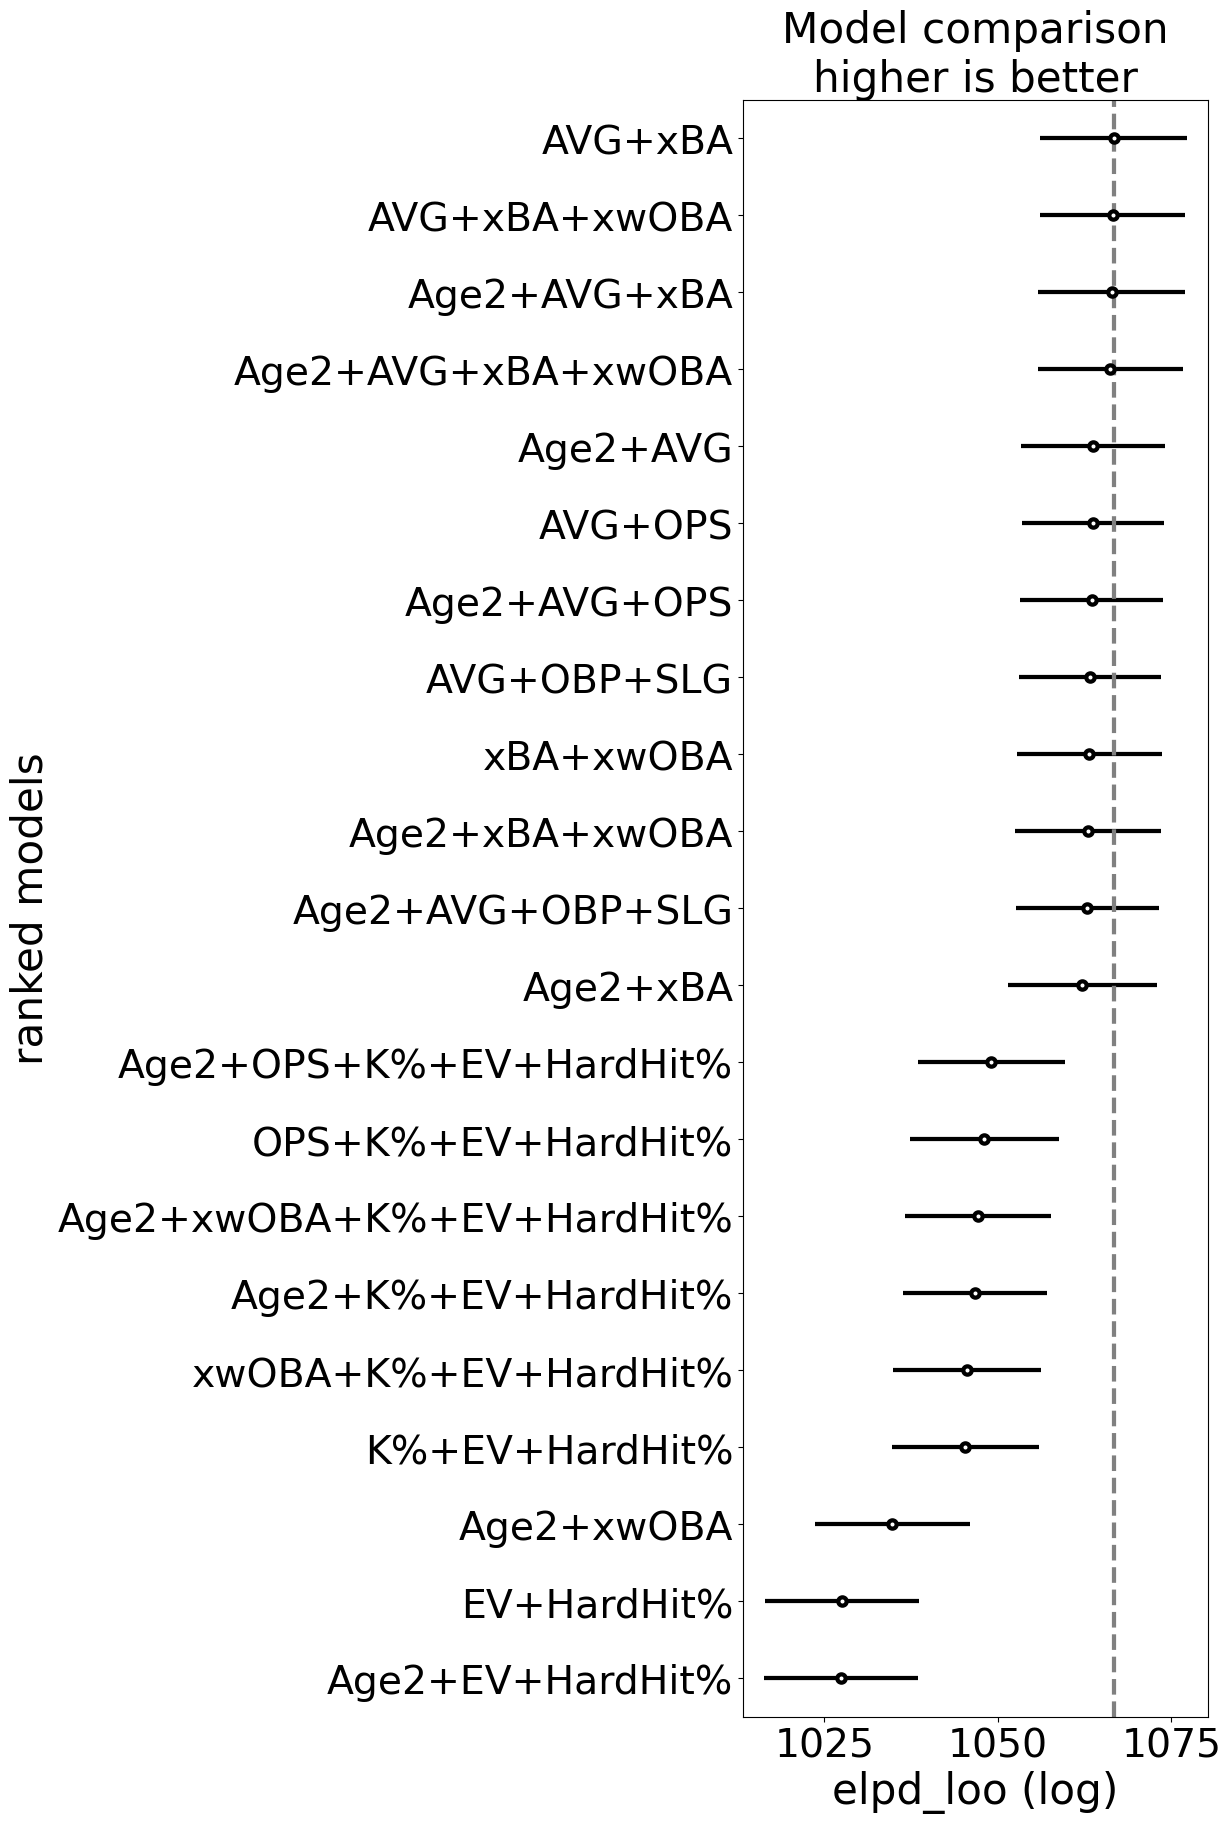

In [8]:
# --- Comparison ---
comparison = az.compare(traces, ic="loo", scale="log")
print(comparison)
az.plot_compare(comparison)
plt.show()